In [1]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
from typing import Union, Dict, Optional, Tuple, Set, List
from math import factorial
import time
from copy import copy
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score
import sklearn
import math

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"sklearn\..*")

In [3]:
# Useful if you run this on google colab and downloaded the data into your drive.
# If you run the notebook in other environment remove these lines and change the 'pd.read_csv()' function in this notebook to read from
# where you saved you data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# import woodelf from Python file in the drive
!cp /content/drive/MyDrive/...../woodelf.py /content/

import woodelf

# PDP Code

In [5]:
class CPDVMetric(woodelf.CubeMetric):
    def calc_metric(self, s_plus: Set, s_minus: Set) -> Dict[str, float]:
        if len(s_plus & s_minus) > 0:
            return {}
        pdp_values = {}
        if len(s_plus) == 1:
            for f in s_plus:
                pdp_values[f] = 1
        if len(s_plus) == 0:
            for f in s_minus:
                pdp_values[f] = -1
        return pdp_values

In [6]:
class PathToValuesMatrixLimitSPlus(woodelf.PathToValuesMatrix):
    # Ignored all cubes with |S^+| > MAX_S_PLUS_SIZE to reduce the complexity element of TL3**D to TL2**D*(D**MAX_S_PLUS_SIZE)
    MAX_S_PLUS_SIZE = NotImplemented

    @classmethod
    def map_patterns_to_cube(cls, features_in_path: List[str]):
        updated_wdnf_table = {0: {0: (set(), set())}}
        current_wdnf_table = None
        for feature in features_in_path:
            current_wdnf_table = updated_wdnf_table
            updated_wdnf_table = {}
            for consumer_pattern in current_wdnf_table:
                updated_wdnf_table[consumer_pattern * 2 + 0] = {}
                updated_wdnf_table[consumer_pattern * 2 + 1] = {}
                for background_pattern in current_wdnf_table[consumer_pattern]:
                    s_plus, s_minus = current_wdnf_table[consumer_pattern][background_pattern]

                    # The implementation is identical to the PathToValuesMatrix.map_patterns_to_cube implementation, except for this if.
                    if len(s_plus | {feature}) <= cls.MAX_S_PLUS_SIZE:
                        updated_wdnf_table[consumer_pattern * 2 + 1][background_pattern * 2 + 0] = (s_plus | {feature}, s_minus) # Rule 1

                    updated_wdnf_table[consumer_pattern * 2 + 0][background_pattern * 2 + 1] = (s_plus, s_minus | {feature}) # Rule 2
                    updated_wdnf_table[consumer_pattern * 2 + 1][background_pattern * 2 + 1] = (s_plus, s_minus) # Rule 3

        return updated_wdnf_table

class PathToValuesMatrixLimitSPlusTo1(PathToValuesMatrixLimitSPlus):
    # We uses the fact CPDVMetric ignored all cubes with |S^+| > 1 to reduce the complexity element of TL3**D to TL2**D*D
    MAX_S_PLUS_SIZE = 1

class PathToValuesMatrixLimitSPlusTo2(PathToValuesMatrixLimitSPlus):
    # We uses the fact PDIVOrder1Or2 ignored all cubes with |S^+| > 2 to reduce the complexity element of TL3**D to TL(2**D)*(D**2)
    MAX_S_PLUS_SIZE = 2

In [7]:
def build_sampled_points_df(data: pd.DataFrame, k: int, seed: int = None):
    """
    Sample k points from every column.
    """
    sample_points_data = {}
    for f in data.columns:
        sample_points_data[f] = list(data[f].sample(k, random_state=seed))
        sample_points_data[f].sort()
    return pd.DataFrame(sample_points_data)[data.columns]

def build_equally_distanced_points_df(data: pd.DataFrame, k: int, percentiles: Tuple[float]):
    """
    Take equally distanced points from each column. The min point will be in the precentile percentiles[0]
    and the max point will be in the precentile percentiles[1].
    This is also the default implementation of sklearn
    """
    sample_points_data = {}
    for f in data.columns:
        low, high = np.percentile(data[f].dropna(), [percentiles[0] * 100, percentiles[1]*100])
        # get k equally spaced points between them
        points = np.linspace(low, high, k)
        sample_points_data[f] = list(points)
        sample_points_data[f].sort()
    return pd.DataFrame(sample_points_data)[data.columns]

def build_points_for_full_pdp(data: pd.DataFrame, model, as_df: bool=True):
    """
    Provide the points that will create a full PDP - a graph the will provide the PDV for every x value.
    Does this by collecting all the threshold values from the model. See Sect. of the paper.
    """
    # load the model
    model_objs = woodelf.load_decision_tree_ensamble_model(model, list(data.columns))

    # collect all the theshold values for each feature
    th_values = {f: [] for f in list(data.columns)}
    for tree in model_objs:
        for node in tree.bfs(including_myself=True, including_leaves=False):
            th_values[node.feature_name].append(node.value)

    # Make sure the thesholds are unique and sort them
    for f in th_values:
        th_values[f] = sorted(list(set(th_values[f])))

    if not as_df:
        return th_values

    # zfill
    max_th_length = max([len(thersholds) for thersholds in th_values.values()])
    for f in th_values:
        th_values[f].extend([0] * (max_th_length - len(th_values[f])) )

    # from the built thershold build the points Data Frame
    return pd.DataFrame(th_values)

In [8]:
def build_points_for_pdp(model, data: pd.DataFrame, k: int = 100, percentiles: Tuple[float] = (0.05, 0.95), sampled: bool = False, seed: int = 42, full_pdp: bool = False, verbose : bool = True):
    start_time = time.time()
    if sampled:
        points_df = build_sampled_points_df(data, k, seed)
    elif full_pdp:
        points_df = build_points_for_full_pdp(data, model)
    else:
        points_df = build_equally_distanced_points_df(data, k, percentiles)
    if verbose:
        print(f"Building the points took: {time.time() - start_time} sec")
    return points_df

def woodelf_pdp(model, data: pd.DataFrame, k: int = 100, accurate: bool = True, centered: bool = True, GPU: bool = False,
                percentiles: Tuple[float] = (0.05, 0.95), sampled: bool = False, seed: int = 42, full_pdp: bool = False):
    """
    Compute all the PDVs needed in order to plot the PDP values of all the features. Use WOODELF!
    """
    points_df = build_points_for_pdp(model, data, k, percentiles, sampled, seed, full_pdp, verbose=True)
    return woodelf_pdp_given_points_df(model, data, points_df, accurate, centered, GPU), points_df

def woodelf_pdp_given_points_df(model, data: pd.DataFrame, sampled_points_df: pd.DataFrame, accurate: bool = True, centered: bool = True, GPU: bool = False):
    """
    Compute all the PDVs of the provided points. Use WOODELF!
    """
    metric=CPDVMetric()
    p2v = PathToValuesMatrixLimitSPlusTo1(metric)
    if accurate:
        pdvs = woodelf.calculate_background_metric(model, consumer_data=sampled_points_df, background_data=data, metric=metric, global_importance=False, GPU=GPU, path_to_matrixes_calculator=p2v)
    else:
        pdvs = woodelf.calculate_path_dependent_metric(model, consumer_data=sampled_points_df, metric=metric, global_importance=False, GPU=GPU, path_to_matrixes_calculator=p2v)
    if centered:
        return pdvs

    avg_prediction = float(model.predict(data).mean())
    for f in pdvs:
        pdvs[f] += avg_prediction
    return pdvs

# Fraud Data + Model

In [9]:
transactions_train = pd.read_parquet('drive/MyDrive/ShapResearch/PDP/Data/ieee_cis_fraud_train.parquet') # columns are train_features + ['isFraud']
transactions_test = pd.read_parquet('drive/MyDrive/ShapResearch/PDP/Data/ieee_cis_fraud_test.parquet') # columns are train_features + ['isFraud']

train_features = [f for f in transactions_train.columns if f != 'isFraud']
fraud_train = transactions_train[train_features]
fraud_test = transactions_test[train_features]

In [10]:
gradient_boosting_model = sklearn.ensemble.HistGradientBoostingRegressor(
    max_iter=100,
    max_depth=6,
    max_leaf_nodes=None,
    # tree_method="hist",  # use 'gpu_hist' if you want GPU support
    random_state=42
)
gradient_boosting_model.fit(fraud_train, transactions_train['isFraud'])

y_pred = gradient_boosting_model.predict(transactions_test[train_features])
print(f"Accuracy: {accuracy_score(transactions_test['isFraud'], y_pred.round())}, F1 score: {f1_score(transactions_test['isFraud'], y_pred.round())}")

Accuracy: 0.9656246824939886, F1 score: 0.365625


## Woodelf PDP computation



In [11]:
full_pdp = woodelf_pdp(gradient_boosting_model, fraud_train, full_pdp=True, accurate = True,  centered = False, GPU = False)

Building the points took: 0.22442340850830078 sec


Preprocessing the trees: 100%|██████████| 100/100 [00:07<00:00, 13.59it/s]


cache misses: 49, cache used: 4406


Computing the values: 100%|██████████| 100/100 [00:00<00:00, 149.44it/s]


In [12]:
full_pdp[0]['TransactionAmt']

array([0.02948528, 0.03050871, 0.03203255, 0.03246342, 0.03247157,
       0.03242924, 0.03237798, 0.03240363, 0.03240157, 0.03240801,
       0.03241552, 0.03245981, 0.03245378, 0.03245596, 0.03253995,
       0.03270054, 0.03272288, 0.03273462, 0.0327441 , 0.03274059,
       0.03275597, 0.03275497, 0.03277371, 0.03271113, 0.03270196,
       0.03270054, 0.03269416, 0.03305873, 0.03307913, 0.03313679,
       0.03313622, 0.03313272, 0.03315865, 0.03317255, 0.0332041 ,
       0.03323415, 0.03325042, 0.03327224, 0.03333608, 0.03344916,
       0.039479  , 0.03962923, 0.03960385, 0.03970738, 0.03971809,
       0.0397659 , 0.03983342, 0.03993559, 0.04013521, 0.04017933,
       0.04616352, 0.04746637, 0.04818754, 0.04889085, 0.04894926,
       0.05065262, 0.05148592, 0.05236348, 0.05254396, 0.05303274,
       0.05304299, 0.05321366, 0.06042469, 0.06050697, 0.05789944,
       0.02948528])

In [13]:
full_pdp[1]['TransactionAmt'].values

array([   6.18  ,    8.3   ,   10.    ,   11.    ,   12.688 ,   14.017 ,
         17.34  ,   19.064 ,   20.    ,   22.97  ,   25.    ,   29.    ,
         33.352 ,   35.    ,   39.    ,   42.559 ,   45.    ,   46.757 ,
         47.95  ,   50.    ,   53.882 ,   54.    ,   55.95  ,   56.95  ,
         58.95  ,   67.95  ,   75.    ,   77.    ,   81.    ,   82.95  ,
         85.118 ,   87.    ,  100.    ,  108.95  ,  113.    ,  119.95  ,
        125.    ,  129.95  ,  132.95  ,  138.966 ,  141.    ,  146.    ,
        150.    ,  161.    ,  169.    ,  180.    ,  193.    ,  200.    ,
        204.97  ,  226.    ,  256.95  ,  269.95  ,  280.    ,  309.95  ,
        335.    ,  362.62  ,  390.    ,  410.3965,  433.95  ,  527.    ,
        664.    ,  774.    ,  884.    , 1006.96  , 1291.45  ,    0.    ])

In [14]:
len(full_pdp[1]['TransactionAmt'].values)

66

In [15]:
import matplotlib.pyplot as plt

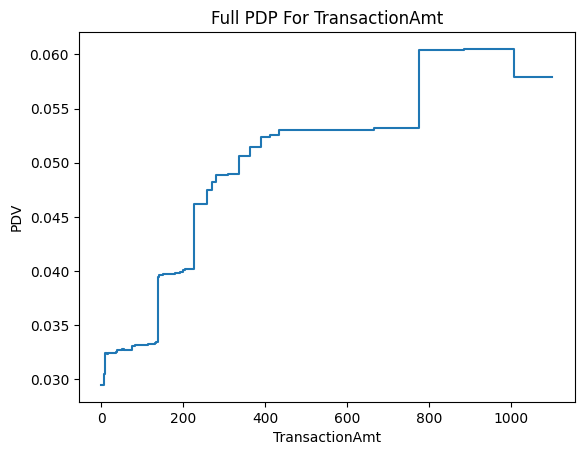

In [16]:
# Add 0 in the begining the trim the graph max X point to be aligned with the regular PDP graphs
plt.step([0] + list(full_pdp[1]['TransactionAmt'].values[:-2]) + [1100], [full_pdp[0]['TransactionAmt'][-1]]  + list(full_pdp[0]['TransactionAmt'][:-1]), where="pre")

plt.xlabel("TransactionAmt")
plt.ylabel("PDV")
plt.title("Full PDP For TransactionAmt")

plt.show()


In [17]:
pdp_k_5 = woodelf_pdp(gradient_boosting_model, fraud_train, k=5, accurate = True,  centered = False, GPU = False, percentiles=(0,0.99))

Building the points took: 3.0356149673461914 sec


Preprocessing the trees: 100%|██████████| 100/100 [00:07<00:00, 13.52it/s]


cache misses: 49, cache used: 4406


Computing the values: 100%|██████████| 100/100 [00:00<00:00, 148.75it/s]


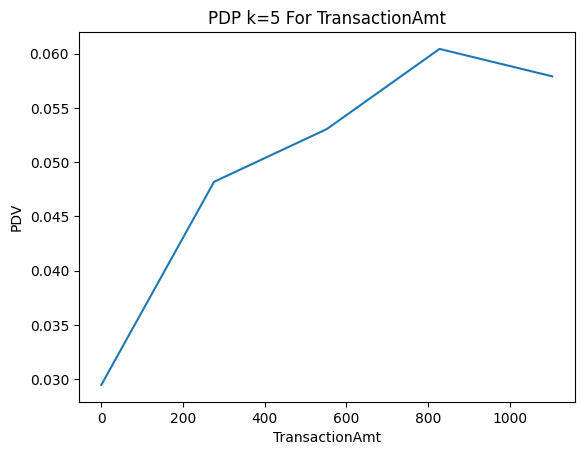

In [18]:
plt.plot(pdp_k_5[1]['TransactionAmt'].values, pdp_k_5[0]['TransactionAmt'])

plt.xlabel("TransactionAmt")
plt.ylabel("PDV")
plt.title("PDP k=5 For TransactionAmt")
plt.show()

In [19]:
pdp_k_20 = woodelf_pdp(gradient_boosting_model, fraud_train, k=20, accurate = True,  centered = False, GPU = False, percentiles=(0,0.99))

Building the points took: 3.0618772506713867 sec


Preprocessing the trees: 100%|██████████| 100/100 [00:07<00:00, 13.51it/s]


cache misses: 49, cache used: 4406


Computing the values: 100%|██████████| 100/100 [00:00<00:00, 149.47it/s]


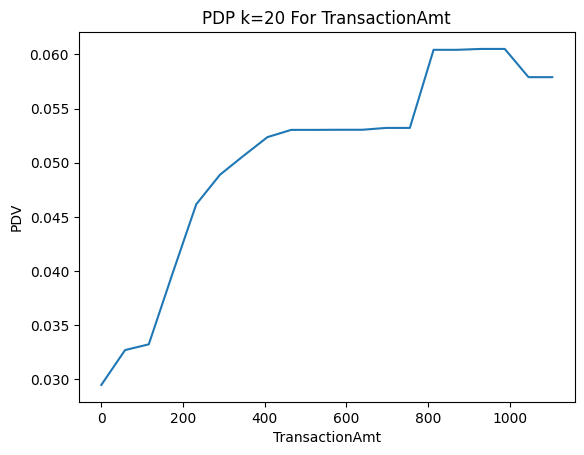

In [20]:
plt.plot(pdp_k_20[1]['TransactionAmt'].values, pdp_k_20[0]['TransactionAmt'])

plt.xlabel("TransactionAmt")
plt.ylabel("PDV")
plt.title("PDP k=20 For TransactionAmt")
plt.show()


In [21]:
pdp_k_100 = woodelf_pdp(gradient_boosting_model, fraud_train, k=100, accurate = True,  centered = False, GPU = False, percentiles=(0,0.99))

Building the points took: 3.0613839626312256 sec


Preprocessing the trees: 100%|██████████| 100/100 [00:07<00:00, 13.49it/s]


cache misses: 49, cache used: 4406


Computing the values: 100%|██████████| 100/100 [00:00<00:00, 148.24it/s]


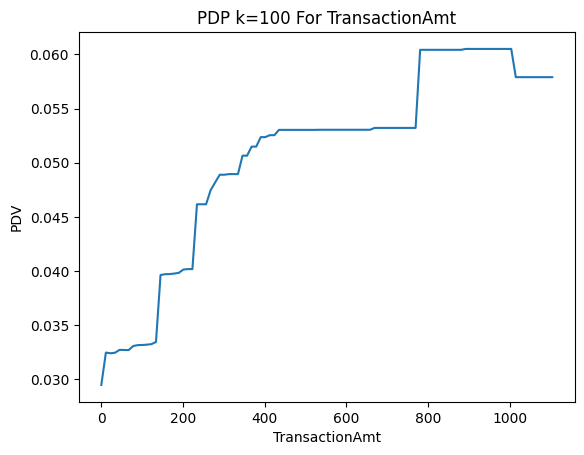

In [22]:
plt.plot(pdp_k_100[1]['TransactionAmt'].values, pdp_k_100[0]['TransactionAmt'])

plt.xlabel("TransactionAmt")
plt.ylabel("PDV")
plt.title("PDP k=100 For TransactionAmt")
plt.show()

In [23]:
plt.rcParams.update({
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 2,
})

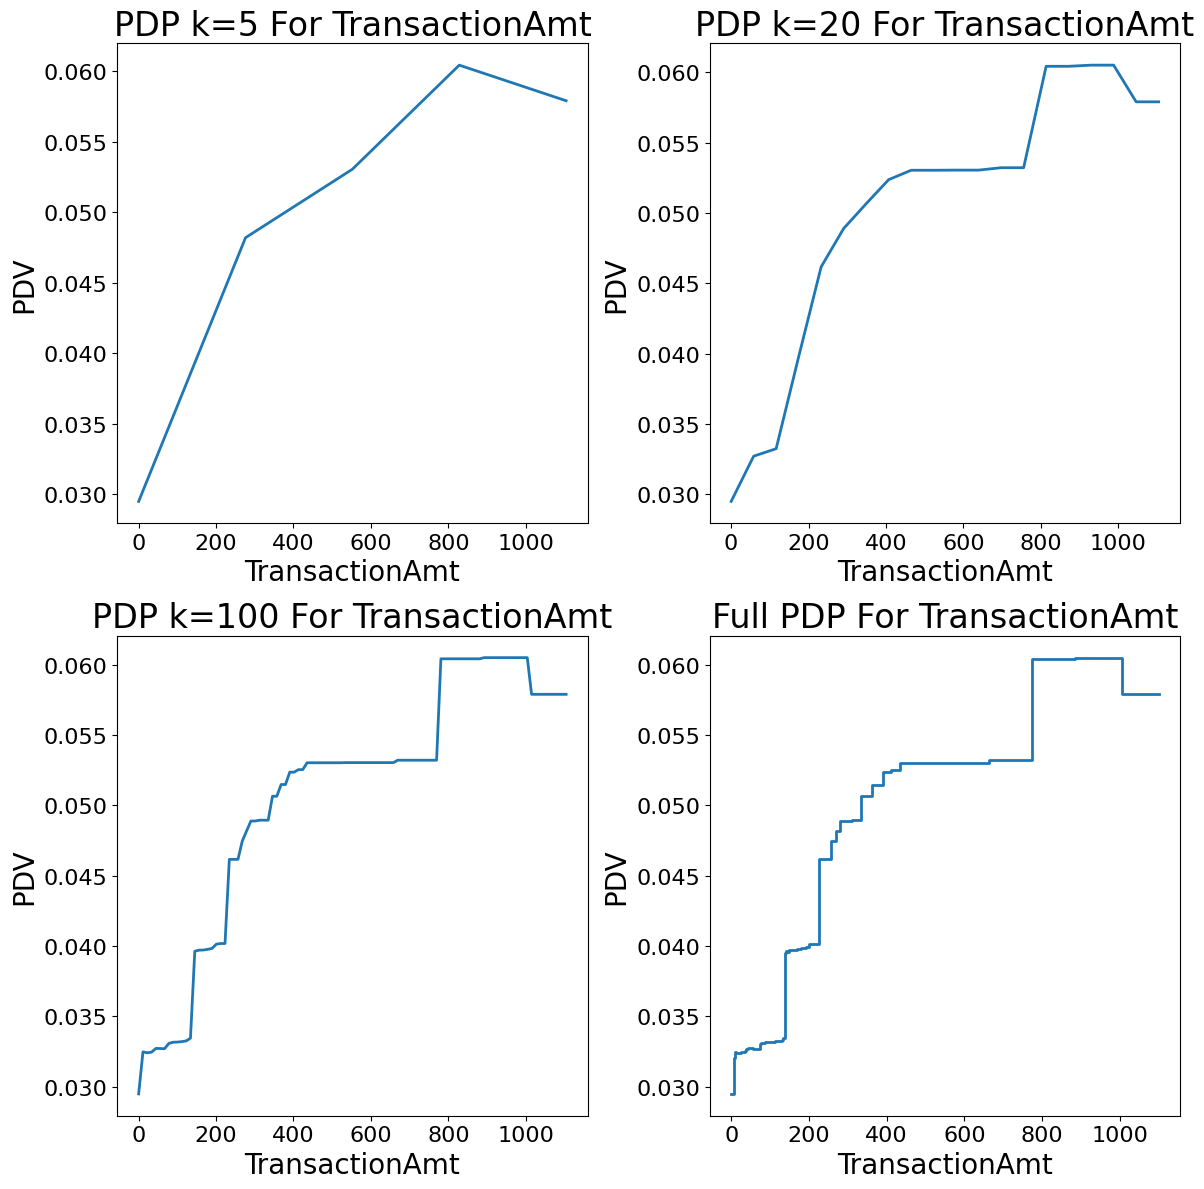

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes_flat= axes.flatten()

ax = axes_flat[0]
ax.plot(pdp_k_5[1]['TransactionAmt'].values, pdp_k_5[0]['TransactionAmt'])
ax.set_xlabel("TransactionAmt")
ax.set_ylabel("PDV")
ax.set_title("PDP k=5 For TransactionAmt")


ax = axes_flat[1]
ax.plot(pdp_k_20[1]['TransactionAmt'].values, pdp_k_20[0]['TransactionAmt'])
ax.set_xlabel("TransactionAmt")
ax.set_ylabel("PDV")
ax.set_title("PDP k=20 For TransactionAmt")

ax = axes_flat[2]
ax.plot(pdp_k_100[1]['TransactionAmt'].values, pdp_k_100[0]['TransactionAmt'])
ax.set_xlabel("TransactionAmt")
ax.set_ylabel("PDV")
ax.set_title("PDP k=100 For TransactionAmt")

ax = axes_flat[3]
# Add 0 in the begining the trim the graph max X point to be aligned with the regular PDP graphs
ax.step([0] + list(full_pdp[1]['TransactionAmt'].values[:-2]) + [1100], [full_pdp[0]['TransactionAmt'][-1]]  + list(full_pdp[0]['TransactionAmt'][:-1]), where="pre")
ax.set_xlabel("TransactionAmt")
ax.set_ylabel("PDV")
ax.set_title("Full PDP For TransactionAmt")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

# Simple PDP Example

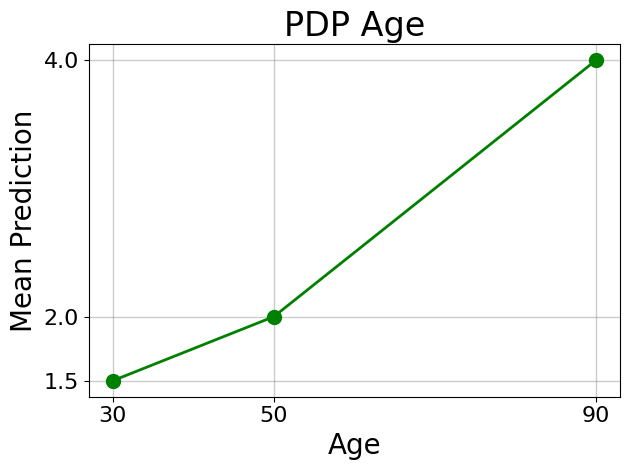

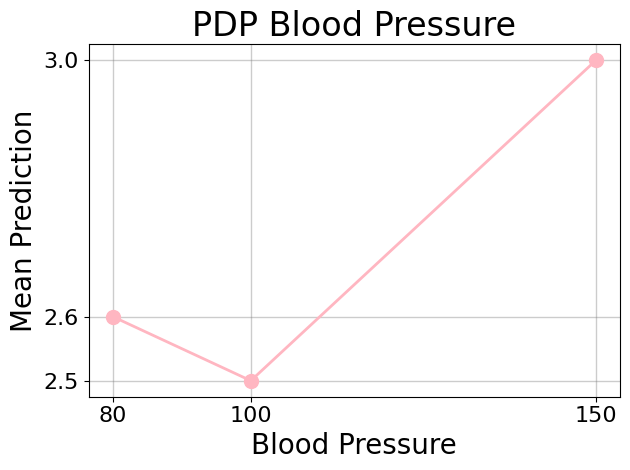

In [25]:
# Data
age = [30, 50, 90]
pdp_age = [1.5, 2.0, 4.0]

bp = [80, 100, 150]
pdp_bp = [2.6, 2.5, 3]

# Colors (matching the example)
green = "green"
pink = "#ffb6c1"   # light pink (similar to the image)

# Plot 1: PDP Age
plt.figure()
plt.plot(age, pdp_age, marker='o', color=green, markersize=10)
plt.xlabel("Age")
plt.ylabel("Mean Prediction")
plt.title("PDP Age")

for x in age:
    plt.axvline(
        x=x,
        color='gray',
        linestyle='-',
        linewidth=1,
        alpha=0.4,
        zorder=1
    )
for y in pdp_age:
    plt.axhline(
        y=y,
        color='gray',
        linestyle='-',
        linewidth=1,
        alpha=0.4,
        zorder=1
    )
plt.xticks(age)
plt.yticks(pdp_age)
plt.tight_layout()
plt.show()

# Plot 2: PDP Blood Pressure
plt.figure()
plt.plot(bp, pdp_bp, marker='o', color=pink, markersize=10)
plt.xlabel("Blood Pressure")
plt.ylabel("Mean Prediction")
plt.title("PDP Blood Pressure")

for x in bp:
    plt.axvline(
        x=x,
        color='gray',
        linestyle='-',
        linewidth=1,
        alpha=0.4,
        zorder=1
    )
for y in pdp_bp:
    plt.axhline(
        y=y,
        color='gray',
        linestyle='-',
        linewidth=1,
        alpha=0.4,
        zorder=1
    )
plt.xticks(bp)
plt.yticks(pdp_bp)
plt.tight_layout()
plt.show()